In [19]:
## The goal of this analysis is to use a random forest model to estimate if a flight will get delayed based on different facors

In [ ]:
# Starting off with some assumptions and predictions. I believe that the departure airport will have the biggest 
# affect on if a flight will get delayed. This is because some airport will naturally experience more weather 
# delayed just due to their location. Also bigger aiports will tend to have more delays as they have more 
# moving parts. 

In [20]:
## The first thing I had to do was import and instal all the add ons that would be needed.
# This included pandas, numpy, and matplotlib

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [3]:
from pathlib import Path

file_path = Path.home() / "Downloads" / "dec 2024 data.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
# I printed the heading and 5 rows just to make sure that the data was loading in correctly

       Date Carrier  Airline Name  Flight_Num Origin Dest  Dep_Time  \
0  12/31/24      9E  Endeavor Air        4780    ATL  TUL       820   
1  12/31/24      9E  Endeavor Air        4780    TUL  ATL      1018   
2  12/31/24      9E  Endeavor Air        4781    ATL  MDT      1110   
3  12/31/24      9E  Endeavor Air        4781    MDT  ATL      1350   
4  12/31/24      9E  Endeavor Air        4783    MDT  ATL       600   

   Actual_Dep  Delay  Cancelled  
0       819.0   -1.0          0  
1      1021.0    3.0          0  
2      1106.0   -4.0          0  
3      1342.0   -8.0          0  
4       607.0    7.0          0  
Index(['Date', 'Carrier', 'Airline Name', 'Flight_Num', 'Origin', 'Dest',
       'Dep_Time', 'Actual_Dep', 'Delay', 'Cancelled'],
      dtype='object')


In [4]:
print(df.info())
print(df.columns.tolist())
# similar thing here, I wanted to display my variables and what they are, whats missing, and the type of data they are

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631944 entries, 0 to 631943
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          631944 non-null  object 
 1   Carrier       631944 non-null  object 
 2   Airline Name  631944 non-null  object 
 3   Flight_Num    631944 non-null  int64  
 4   Origin        631944 non-null  object 
 5   Dest          631944 non-null  object 
 6   Dep_Time      631944 non-null  int64  
 7   Actual_Dep    627666 non-null  float64
 8   Delay         627635 non-null  float64
 9   Cancelled     631944 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 48.2+ MB
None
['Date', 'Carrier', 'Airline Name', 'Flight_Num', 'Origin', 'Dest', 'Dep_Time', 'Actual_Dep', 'Delay', 'Cancelled']


In [6]:
df["Delayed"] = (df["Delay"] > 15).astype(int)

print(df[["Delay", "Delayed"]].head())
print(df["Delayed"].value_counts())

# The first thing I did was make a new variable called "Delayed" and what this does is tell us when a flight has 
# been delayed more then 15 minutes. I chose 15 minutes to be the cutoff but this can be changed to 10 or 5 or even 0

   Delay  Delayed
0   -1.0        0
1    3.0        0
2   -4.0        0
3   -8.0        0
4    7.0        0
0    501458
1    130486
Name: Delayed, dtype: int64


In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")

df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Because "Date" is classified as a string, and my model cant interpret strings, I had to convert it to a datetime format
# From the date, I created three variables, month, day, and day of week, 0 being monday, 6 being sunday
# This allows me to look at multiple differnt factors.

In [8]:
features = [
    "Carrier",
    "Airline Name",
    "Flight_Num",
    "Origin",
    "Dest",
    "Dep_Time",
    "Month",
    "Day",
    "DayOfWeek"
]

X = df[features]
y = df["Delayed"]

# In this step, I defined the predictor variables (features) used to train the model.
# These features represent information that is available before a flight departs and may influence whether a 
# delay occurs.
# These factors may capture operational patterns such as busy airports, airline scheduling practices, and time-related delay trends.
# The dataset is then split into two components:
# X (features):The predictor variables used by the model to make predictions.
# y (target variable):The outcome the model is trying to predict.
# The target variable is "Delayed", a binary variable

In [21]:
from sklearn.preprocessing import LabelEncoder

X = X.copy()

label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Random forest models cant use text, so I had to convert all the text into numbers. What this code does is 
# give each unique text a number value, allowing me to run my random forest.
# At the end, I have it coded to return the numerical value back into the original text

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Here in this step, my goal was to split the data set into testing and training. 
# The training set is used to train my model to learn patterns within the data
# The test set is used to see how well the trained model preformed with unseen data.
# 80% is used for training, 20% for testing
# stratify=y is used to ensure each set gets the same proportion of delayed and on time flights


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# in this step I actually created the random forest model, set peramiters, and trained the model. 

RandomForestClassifier(n_jobs=-1, random_state=42)

In [15]:
y_pred = rf_model.predict(X_test)

# This step is used as my preditions after training my model

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# In this step, i looked at how accurate my model was basked off the real data
# Accuracy – the overall proportion of correct predictions made by the model.
# Precision – the proportion of predicted delayed flights that were actually delayed.
# Recall – the proportion of actual delayed flights that the model correctly identified.
# F1-score – the mean of precision and recall, which balances the two metrics.
# Confusion Matrix – a table that summarizes correct and incorrect predictions made by the model.


Accuracy: 0.8042630292193149

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.96      0.89    100292
           1       0.57      0.21      0.31     26097

    accuracy                           0.80    126389
   macro avg       0.70      0.59      0.60    126389
weighted avg       0.77      0.80      0.77    126389


Confusion Matrix:

[[96083  4209]
 [20530  5567]]


In [ ]:
## Output:
# An accuracy of 0.8 means that the model was right roughly 80% of the time. So about four out of five flights were
# correctly classified as delayed or on time.
# When looking at recall, we can see that the model is much better at determining on time flights rather then
# delayed flights. It correctly predicts 96% of on time flights, but only about 21% of delayed flights. Meaning
# that it predicts many delayed flights to actually be on time.

# When looking at the confusion matrix, the model correctly predicted 96,083 on time flights but incorrectly
# predicted 4,209 flights as delayed when they were actually on time. Additionally, the model failed to
# detect 20,530 delayed flights while correctly identifying 5,567 delayed flights. Supporting the fact that the 
# model was much better at supporting on time flights rather then delayed flights. I think these numebrs would 
# change if I lowered the delayed time to lets say 5 minutes rather then 15. The model currently sees alot more 
# on time flights so they are better at predicting them.

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# The goal of this step is to find out which variabels were used the most in predicting if a flight will get delayed
# Basically saying, which variables are most important to use

        Feature  Importance
2    Flight_Num    0.230764
5      Dep_Time    0.230763
4          Dest    0.162362
3        Origin    0.153301
7           Day    0.110980
8     DayOfWeek    0.057304
1  Airline Name    0.027521
0       Carrier    0.027005
6         Month    0.000000


In [ ]:
## Output:
# This shows which factors were the most influential in the model determining which flights would get delayed.
# The higher the number, the more the model relied on that variable to predict outcomes. 
# The output shows us that flight number is the most important variable. A flight number is a code that is used 
# to explain a flight path at a certin time. For example AA1234 could potentally mean, American Airlines flight that
# flys from BWI to SDF at 8:30am. So this tells us that certain routes and times are very important and can lead to
# being a very good predictor. 
# The next most important variable was departure time. So whether its morning flights, night flights, or something
# in between, the time of day is very important.
# Month is shown as zero since December is the only month in my dataset. 

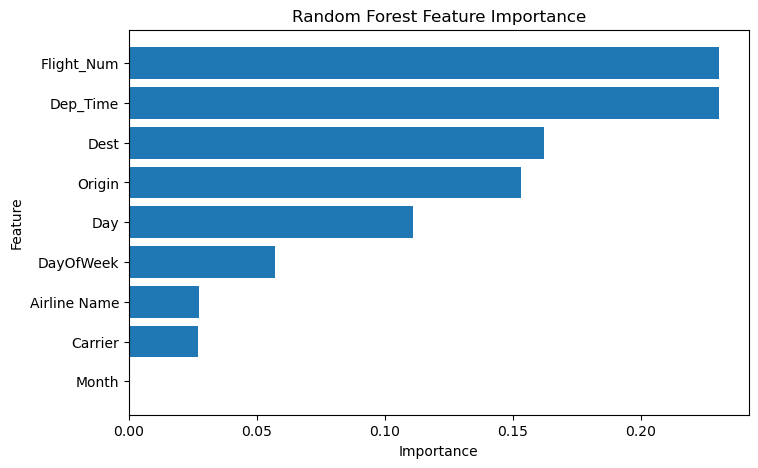

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Finally, here I just wanted to turn those numbers into a visual graph.

In [ ]:
# So in the end, my originally prediction was incorrect. Departing airport was the 4th most influential factor with
# 0.15. While this is still important, its not the most important. 